In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from joblib import Parallel, delayed

from scipy.special import iv

import pickle

import schwingerModel as sim

In [2]:
with open('configs/50kSteps.pkl', 'rb') as f:
    temp = pickle.load(f)

In [3]:
m = temp.fMass
a = temp.a
dimx = temp.dimx
dimt = temp.dimt
beta = temp.beta
totalSteps = temp.metroSteps

print(m)
print(a)
print(dimx)
print(dimt)
print(beta)
print(totalSteps)

0.2
1
16
32
10
50000


In [ ]:
rhoBar = sim.analysis.getNumDensityRhoBar(temp, burnIn=0, chemicalPot=0.5)
tau_int, err, W = sim.analysis.get_integrated_autocorr_time_statistical(rhoBar, N_conf=len(rhoBar))
print(f"Integrated autocorrelation time: {tau_int}")

In [4]:
#calculate pseudo-scalar mass for this lattice
bIn = 0
skp = 50
correl = sim.distillation.correlStats(temp, burnIn=bIn,autocorrSkip=skp,nVec=2)
piv = 4
mass = sim.distillation.correlMassExtract(correl,fitT=[piv,8],diagCov=False)
mass

configs:   0%|          | 0/1000 [00:00<?, ?it/s]

array([0.55622721, 0.00074965])

In [5]:
bIn = 0
skp = 250
mus = np.linspace(0,1,24)

densities = Parallel(n_jobs=12)(delayed(sim.analysis.numDensityStats)(temp,burnIn=bIn,autocorrSkip=skp, chemicalPot=mu) for mu in mus)

100%|██████████| 200/200 [01:04<00:00,  3.09it/s]


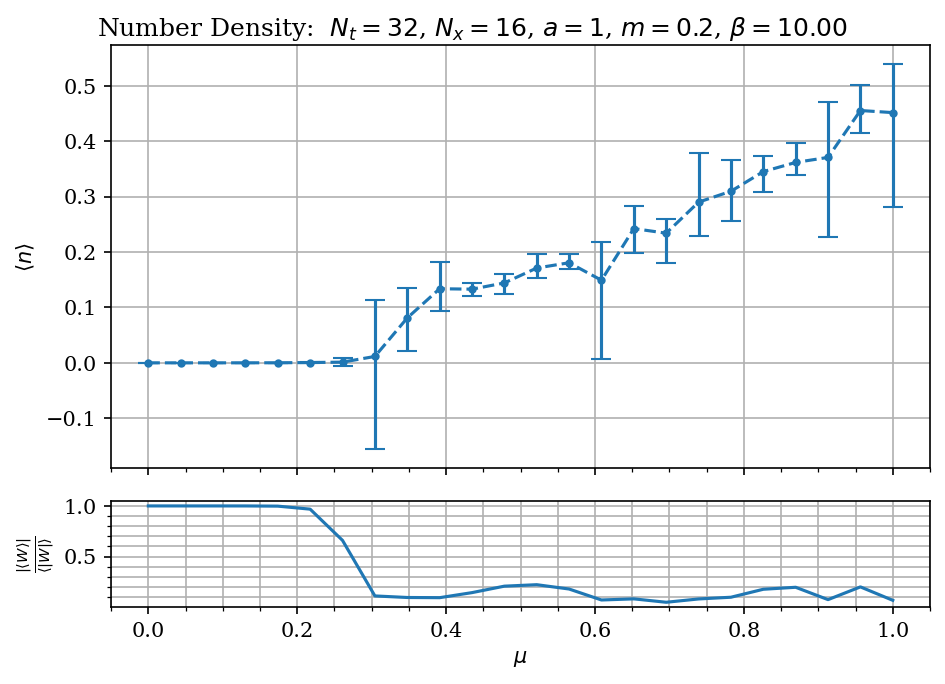

In [6]:
dens = np.array([densities[i][0] for i in range(len(densities))])
densErr = np.array([densities[i][1] for i in range(len(densities))]).T
validity = np.array([densities[i][2] for i in range(len(densities))])

fig, ax = plt.subplots(dpi=150, nrows=2, height_ratios=[4,1],sharex=True)

# ax[0].errorbar(x=mus/mass[0],y=temp.a*dens,yerr=np.abs(densErr),capsize=5, marker=".",ls="--")
ax[0].errorbar(x=mus,y=temp.a*dens,yerr=np.abs(densErr),capsize=5, marker=".",ls="--")
ax[0].set_ylabel(r"$\langle n\rangle$")
ax[0].grid()
# ax[1].set_xlabel(r"$\mu/m_\text{ps}$")
ax[1].set_xlabel(r"$\mu$")

# ax[1].plot(mus/mass[0],validity)
ax[1].plot(mus,validity)
ax[1].set_ylabel(r"$\frac{|\langle W\rangle|}{\langle |W| \rangle}$")
ax[1].minorticks_on()
ax[1].grid(which="both")

fig.suptitle(rf"Number Density:  $N_t = {dimt}$, $N_x={dimx}$, $a={a}$, $m={m}$, $\beta={beta:.2f}$",y=.94)
plt.tight_layout()

In [8]:
validity

array([1.        , 0.99999957, 0.99999213, 0.99987194, 0.99793943,
       0.9680502 , 0.65969813, 0.11089061, 0.09545812, 0.09355912,
       0.14347304, 0.20730746, 0.22190429, 0.17908698, 0.07076995,
       0.08187807, 0.04826286, 0.08098914, 0.09793392, 0.17667295,
       0.19636257, 0.07425072, 0.20010173, 0.06763439])